In [1]:
import numpy as np
import os 

from utils.cfd_functions_pre import read_boundary_patches, write_openfoam_field

from utils.cfd_functions_post import readWaveGauge, get_waveparams_from_gauge

In [2]:
Ncells = 51591
Uvec = np.zeros((Ncells, 3))
p_rgh_vec = np.zeros(Ncells)
alphaCol = np.zeros(Ncells)  # Replace with your alpha initial field if needed

# -----------------------
# Read boundary patches
# -----------------------
boundary_file = os.path.join(
    'outputs/openfoam_cases_backup/0000/constant/polyMesh/boundary'
)
patches = read_boundary_patches(boundary_file)

alpha_inlet_patch_vals = []  

write_openfoam_field(
    output_file="U",
    class_name="volVectorField",
    dims=[0, 1, -1, 0, 0, 0, 0],
    internal_data=Uvec,
    patches=patches,
    field_name="U",
    location="0",
    alpha_inlet_patch_vals=alpha_inlet_patch_vals,
)

write_openfoam_field(
    output_file="p_rgh",
    class_name="volScalarField",
    dims=[1, -1, -2, 0, 0, 0, 0],
    internal_data=p_rgh_vec,
    patches=patches,
    field_name="p_rgh",
    location="0",
    alpha_inlet_patch_vals=alpha_inlet_patch_vals,
)

write_openfoam_field(
    output_file="alpha.water",
    class_name="volScalarField",
    dims=[0, 0, 0, 0, 0, 0, 0],
    internal_data=alphaCol,
    patches=patches,
    field_name="alpha.water",
    location="0",
    force_nonuniform=True,
    alpha_inlet_patch_vals=alpha_inlet_patch_vals,
)


In [3]:
df = readWaveGauge(case_dir='outputs/openfoam_cases_backup/0000',func_name='surfaceElevationAnyName')

In [9]:
df[0].index = df[0].index.round(2)

In [10]:
df[1].index = df[1].index.round(2)

In [11]:
df[0]

,gauge_0,gauge_1,gauge_2,gauge_3,gauge_4,gauge_5,gauge_6,gauge_7,gauge_8,gauge_9,gauge_10
Time,,,,,,,,,,,
0.02,1.82000,1.82000,1.82000,1.82000,1.82000,1.820000,1.82000,1.82000,1.82000,1.82000,1.78306
0.04,1.82000,1.82000,1.82000,1.82000,1.82000,1.820000,1.82000,1.82000,1.82000,1.82000,1.78305
0.06,1.82000,1.82000,1.82000,1.82000,1.82000,1.820000,1.82000,1.82000,1.82000,1.82000,1.78304
0.08,1.82000,1.82000,1.82000,1.82000,1.82000,1.820000,1.82000,1.82000,1.82000,1.82000,1.78304
0.10,1.82000,1.82000,1.82000,1.82000,1.82000,1.820000,1.81999,1.82000,1.82000,1.82000,1.78303
...,...,...,...,...,...,...,...,...,...,...,...
486.56,2.33883,1.31644,1.84053,1.64736,2.45358,0.632281,2.63705,1.71331,1.43467,1.63285,1.65014
486.58,2.33699,1.31293,1.84225,1.64702,2.43345,0.628953,2.62311,1.70968,1.44102,1.63109,1.65194
486.60,2.33527,1.31006,1.84374,1.64678,2.41635,0.626227,2.61140,1.70661,1.44666,1.62960,1.65349


In [12]:
df[1]

,gauge_0,gauge_1,gauge_2,gauge_3,gauge_4,gauge_5,gauge_6,gauge_7,gauge_8,gauge_9,gauge_10
Time,,,,,,,,,,,
486.52,2.34136,1.32238,1.83787,1.64802,2.48606,0.637931,2.65990,1.71919,1.42503,1.63570,1.64729
486.54,2.34017,1.31939,1.83917,1.64767,2.46998,0.635090,2.64853,1.71628,1.42971,1.63429,1.64869
486.56,2.33883,1.31644,1.84053,1.64736,2.45358,0.632281,2.63705,1.71331,1.43467,1.63285,1.65014
486.58,2.33699,1.31293,1.84225,1.64702,2.43345,0.628953,2.62311,1.70969,1.44102,1.63109,1.65194
486.60,2.33527,1.31006,1.84374,1.64677,2.41635,0.626227,2.61140,1.70661,1.44666,1.62961,1.65349
486.62,2.33337,1.30724,1.84530,1.64657,2.39892,0.623546,2.59958,1.70347,1.45264,1.62809,1.65510
486.64,2.33131,1.30447,1.84692,1.64641,2.38121,0.620917,2.58768,1.70029,1.45899,1.62655,1.65675


In [6]:
import pandas as pd
data = pd.read_csv('outputs/openfoam_cases_backup/0000/postProcessing/surfaceElevationAnyName/0/surfaceElevation.dat', sep='\t', header=0)

<Axes: xlabel='Time'>

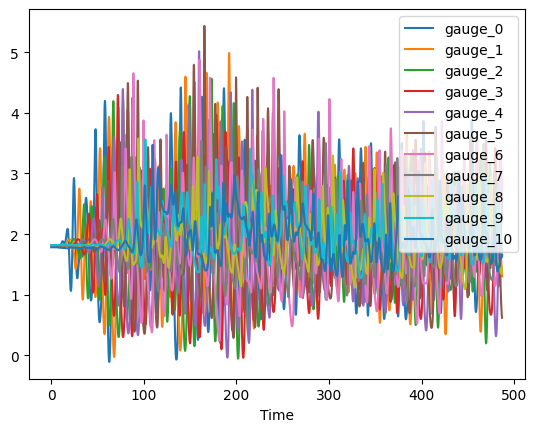

In [7]:
df.plot()

In [8]:
get_waveparams_from_gauge(df) - 1.8

,Hrms,Hs,Hss,Hig,Hvlf,Setup
gauge_0,0.491324,-0.030084,-0.188035,-1.8,-1.8,0.063530
gauge_1,0.474921,-0.054670,-0.213424,-1.8,-1.8,0.066075
gauge_2,0.465503,-0.121798,-0.274220,-1.8,-1.8,0.064365
gauge_3,0.495821,-0.123227,-0.272868,-1.8,-1.8,0.059758
gauge_4,0.533602,-0.021622,-0.178450,-1.8,-1.8,0.059840
gauge_5,0.509727,0.080678,-0.085618,-1.8,-1.8,0.051656
gauge_6,0.375439,0.031089,-0.117604,-1.8,-1.8,0.047862
gauge_7,-0.430567,-0.739433,-0.822704,-1.8,-1.8,0.076490
gauge_8,-0.709161,-0.968314,-1.032863,-1.8,-1.8,0.132012
gauge_9,-0.788988,-1.025703,-1.090086,-1.8,-1.8,0.186379
